SENTIMENT ANALYSIS USING NLP & MACHINE LEARNING

[STEP 1] Loading Twitter dataset...
✓ Dataset loaded successfully
Dataset Shape: (162980, 2)

[STEP 2] Data Exploration

Sentiment Distribution:
sentiment
Positive    72250
Neutral     55213
Negative    35510
Name: count, dtype: int64


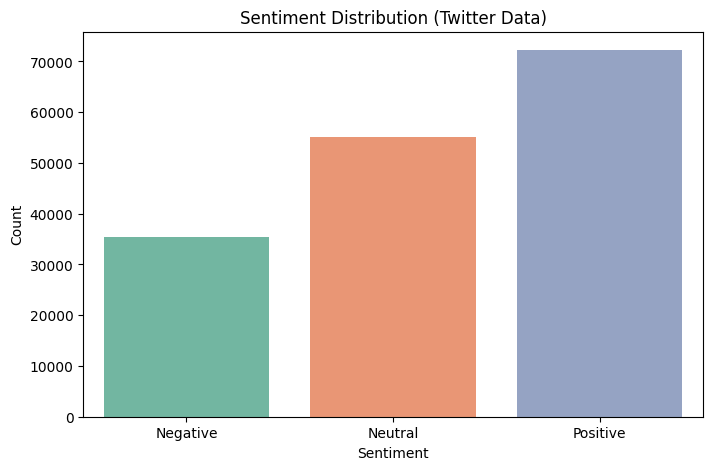


[STEP 3] Data Cleaning
✓ Data cleaned
Final Dataset Size: (162969, 2)

[STEP 4] Text Preprocessing
✓ Text preprocessing completed

[STEP 5] Feature Engineering
✓ TF-IDF features created

[STEP 6] Model Training
Naive Bayes Accuracy: 0.7312
Logistic Regression Accuracy: 0.8730
Support Vector Machine Accuracy: 0.8817

✓ Best Model: Support Vector Machine

[STEP 7] Model Evaluation

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.77      0.81      7102
     Neutral       0.85      0.96      0.90     11042
    Positive       0.92      0.88      0.90     14450

    accuracy                           0.88     32594
   macro avg       0.88      0.87      0.87     32594
weighted avg       0.88      0.88      0.88     32594



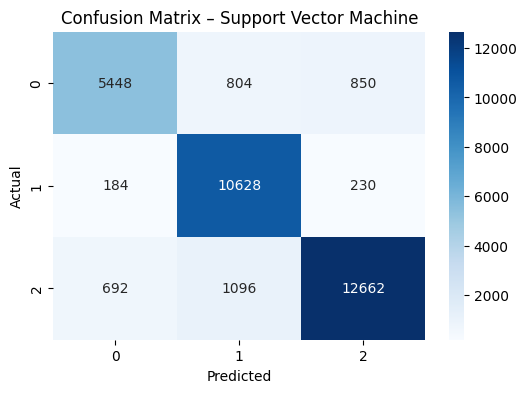


[STEP 8] Model Comparison


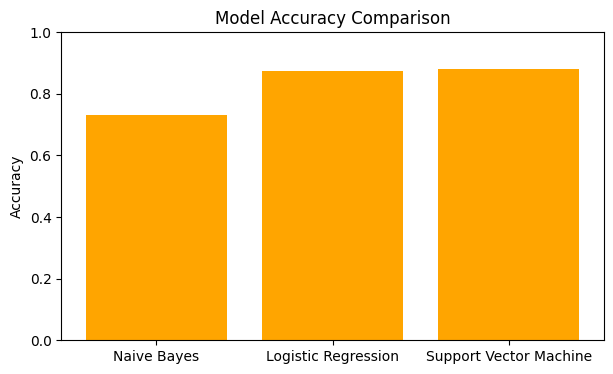


[STEP 9] Sentiment Prediction

Text: I love this product, it is amazing
Predicted Sentiment: Positive

Text: Worst experience ever
Predicted Sentiment: Negative

Text: It is okay, not bad but not great
Predicted Sentiment: Positive

PROJECT COMPLETED SUCCESSFULLY

• Sentiment analysis performed on Twitter public opinion data
• NLP techniques used for text understanding
• TF-IDF applied for feature extraction
• Multiple ML models trained and compared
• Best model selected based on accuracy
• Results visualized for clear interpretation



In [1]:
# ============================================================
# SENTIMENT ANALYSIS PROJECT - Oasis Infobyte Internship
# Project : SENTIMENT ANALYSIS USING NLP & MACHINE LEARNING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings("ignore")

# ML & NLP
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

print("="*70)
print("SENTIMENT ANALYSIS USING NLP & MACHINE LEARNING")
print("="*70)

# ============================================================
# STEP 1: LOAD DATASET (TWITTER)
# ============================================================
print("\n[STEP 1] Loading Twitter dataset...")

df = pd.read_csv("Twitter_Data.csv")
df = df[['clean_text', 'category']]
df.columns = ['text', 'sentiment']

# Convert numeric labels to text
df['sentiment'] = df['sentiment'].map({
    -1: 'Negative',
     0: 'Neutral',
     1: 'Positive'
})

print(" Dataset loaded successfully")
print("Dataset Shape:", df.shape)

# ============================================================
# STEP 2: DATA EXPLORATION
# ============================================================
print("\n[STEP 2] Data Exploration")

print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='sentiment', palette='Set2')
plt.title("Sentiment Distribution (Twitter Data)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

# ============================================================
# STEP 3: DATA CLEANING
# ============================================================
print("\n[STEP 3] Data Cleaning")

df.dropna(inplace=True)
df.drop_duplicates(subset='text', inplace=True)

print(" Data cleaned")
print("Final Dataset Size:", df.shape)

# ============================================================
# STEP 4: TEXT PREPROCESSING (NLP)
# ============================================================
print("\n[STEP 4] Text Preprocessing")

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    words = [
        lemmatizer.lemmatize(word)
        for word in text.split()
        if word not in stop_words and len(word) > 2
    ]
    return " ".join(words)

df['cleaned_text'] = df['text'].apply(clean_text)

print(" Text preprocessing completed")

# ============================================================
# STEP 5: FEATURE ENGINEERING (TF-IDF)
# ============================================================
print("\n[STEP 5] Feature Engineering")

X = df['cleaned_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(" TF-IDF features created")

# ============================================================
# STEP 6: MODEL TRAINING
# ============================================================
print("\n[STEP 6] Model Training")

from sklearn.svm import LinearSVC

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Support Vector Machine": LinearSVC()
}


results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("\n Best Model:", best_model_name)

# ============================================================
# STEP 7: MODEL EVALUATION
# ============================================================
print("\n[STEP 7] Model Evaluation")

y_pred_best = best_model.predict(X_test_tfidf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix – {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================================================
# STEP 8: MODEL COMPARISON
# ============================================================
print("\n[STEP 8] Model Comparison")

plt.figure(figsize=(7,4))
plt.bar(results.keys(), results.values(), color='orange')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

# ============================================================
# STEP 9: SENTIMENT PREDICTION
# ============================================================
print("\n[STEP 9] Sentiment Prediction")

def predict_sentiment(text):
    cleaned = clean_text(text)
    vector = tfidf.transform([cleaned])
    return best_model.predict(vector)[0]

samples = [
    "I love this product, it is amazing",
    "Worst experience ever",
    "It is okay, not bad but not great"
]

for s in samples:
    print(f"\nText: {s}")
    print("Predicted Sentiment:", predict_sentiment(s))

# ============================================================
# STEP 10: CONCLUSION
# ============================================================
print("\n" + "="*70)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*70)

print("""
• Sentiment analysis performed on Twitter public opinion data
• NLP techniques used for text understanding
• TF-IDF applied for feature extraction
• Multiple ML models trained and compared
• Best model selected based on accuracy
• Results visualized for clear interpretation
""")
